# Asignación A3: Clasificador de Dígitos Manuscritos con Support Vector Machines (SVM)

**Maestría en Ingeniería en Inteligencia Artificial Aplicada**  
**Asignatura:** Machine Learning y Análisis de Patrones · Bloque I  
**Docente:** Dr. Héctor M. Morales-Fajardo  
**Estudiante:** Brandon Cereceda  

---

## 1. Objetivos y Fundamentación Metodológica

El objetivo central de esta asignación es diseñar, entrenar, optimizar y evaluar de manera rigurosa un sistema de reconocimiento de dígitos manuscritos ($0$ al $9$) basado en **Máquinas de Vectores de Soporte (Support Vector Machines, SVM)**, investigando en profundidad el impacto de la función de **kernel** y de los hiperparámetros de regularización ($C$) y dispersión del núcleo ($\gamma$).

### Fundamento Teórico de las Máquinas de Vectores de Soporte:
Las SVM (Cortes & Vapnik, 1995) son clasificadores supervisados basados en el principio de **Minimización del Riesgo Estructural (SRM)**, cuyo propósito es encontrar un hiperplano separador óptimo en un espacio de características de alta dimensión que maximice el **margen geométrico** entre clases:

$$\max_{w, b} \frac{2}{\|w\|} \quad \Longleftrightarrow \quad \min_{w, b} \frac{1}{2} \|w\|^2$$

Para conjuntos de datos no linealmente separables en el espacio original, se introduce una formulación de **margen suave (*soft margin*)** mediante variables de holgura $\xi_i \ge 0$ y una constante de regularización $C > 0$:

$$\min_{w, b, \xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^N \xi_i \quad \text{sujeto a} \quad y_i (w^T \phi(x_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$

Mediante la teoría de dualidad de Wolfe y las condiciones de Karush-Kuhn-Tucker (KKT), el problema dual se formula como:

$$\max_{\alpha} \sum_{i=1}^N \alpha_i - \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j K(x_i, x_j) \quad \text{sujeto a} \quad 0 \le \alpha_i \le C, \quad \sum_{i=1}^N \alpha_i y_i = 0$$

Donde $K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$ es una función de **kernel** válida según el **Teorema de Mercer**. Solo las muestras para las cuales $\alpha_i > 0$ se convierten en **vectores de soporte (Support Vectors)**, determinando completamente la frontera de decisión:

$$f(x) = \text{sign}\left( \sum_{i \in \text{SV}} \alpha_i y_i K(x_i, x) + b \right)$$

### Funciones de Kernel Evaluadas:
1. **Kernel Lineal:** $K(x, z) = x^T z$
2. **Kernel Polinomial:** $K(x, z) = (\gamma x^T z + r)^d$ (con $d=3$, grado cúbico estándar)
3. **Kernel de Base Radial Gaussiana (RBF):** $K(x, z) = \exp(-\gamma \|x - z\|^2)$
4. **Kernel Sigmoidal (Tangente Hiperbólica):** $K(x, z) = \tanh(\gamma x^T z + r)$

---

### Metodología de Experimentación:
1. **Preprocesamiento:** Normalización/Estandarización rigurosa de las intensidades de píxeles mediante `StandardScaler` ajustado únicamente sobre el conjunto de entrenamiento para evitar cualquier tipo de fuga de datos (*data leakage*).
2. **Comparativa Multifactorial de Kernels:** Evaluación empírica de al menos 3 kernels (`linear`, `poly`, `rbf`, más `sigmoid`) registrando tiempo de entrenamiento ($s$), tiempo de inferencia ($ms$), exactitud (*Accuracy*) y número de vectores de soporte.
3. **Análisis del Trade-off Computacional vs. Desempeño:** Presentación de tabla comparativa cuantitativa y figura gráfica de dispersión anotada.
4. **Optimización con RandomizedSearchCV:** Búsqueda aleatoria de hiperparámetros en escala log-continua sobre $C \in [10^{-1}, 10^3]$ y $\gamma \in [10^{-4}, 10^0]$ con validación cruzada estratificada de 5 pliegues (*5-Fold Stratified CV*).
5. **Visualización Geométrica con PCA (2D):** Proyección del espacio de 64 dimensiones a 2 componentes principales y visualización de la posición espacial de los vectores de soporte respecto a los cúmulos de cada dígito.
6. **Evaluación Diagnóstica y Análisis de Confusión:** Generación de matriz de confusión de alta resolución, reporte de métricas por clase (`precision`, `recall`, `f1-score`) y análisis visual de los dígitos erróneamente clasificados.
7. **Discusión de Media Cuartilla y Justificación de Kernel:** Análisis técnico formal del balance entre precisión predictiva y costo computacional para la toma de decisiones en ingeniería.

In [1]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform

# Scikit-learn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 150

# Creación de directorio de resultados
os.makedirs("results", exist_ok=True)


## 2. Datos: Exploración, Partición y Preprocesamiento

### Dataset Utilizado (`sklearn.datasets.load_digits`):
El dataset *Optical Recognition of Handwritten Digits* consiste en imágenes digitalizadas de dígitos manuscritos normalizados en matrices de **$8 \times 8$ píxeles** ($64$ características por muestra), con intensidades discretas en el rango $[0, 16]$. Cuenta con **1,797 instancias balanceadas** distribuidas de forma casi uniforme entre las 10 clases ($0$ a $9$).

> **Nota Metodológica sobre MNIST vs. load_digits:**  
> La instrucción del ejercicio permite utilizar MNIST o `load_digits` cuando el costo computacional es un factor restrictivo. En MNIST completo ($N = 70,000$ muestras y $D = 784$ dimensiones), el entrenamiento de SVM no lineales con LibSVM escala con una complejidad temporal de entre $\mathcal{O}(N^2 \cdot D)$ y $\mathcal{O}(N^3)$, requiriendo horas de procesamiento para validación cruzada y afinamiento de hiperparámetros. El uso de `load_digits` provee una representación matemática idéntica de imágenes manuscritas multiclase, asegurando que el notebook pueda ser ejecutado de principio a fin de manera eficiente, reproducible y sin riesgo de cuelgues (*Kernel -> Restart & Run All* limpio).

### Justificación del Escalado:
Las SVM calculan productos punto $x_i^T x_j$ o distancias euclídeas $\|x_i - x_j\|^2$ para evaluar los kernels. Si las variables presentan varianzas heterogéneas o desfases de escala, los atributos de mayor magnitud dominarían artificialmente el cálculo del margen. Aplicamos `StandardScaler` ($\mu=0, \sigma=1$) ajustado **exclusivamente sobre el conjunto de entrenamiento (`X_train`)** y transformando posteriormente `X_test`, previniendo de forma estricta cualquier fuga de información (*data leakage*).

Número total de muestras: 1797
Dimensiones por imagen (atributos): 64 (imágenes de 8x8 píxeles)
Clases únicas: [0 1 2 3 4 5 6 7 8 9] (dígitos del 0 al 9)
Muestras de entrenamiento: 1257
Muestras de prueba: 540


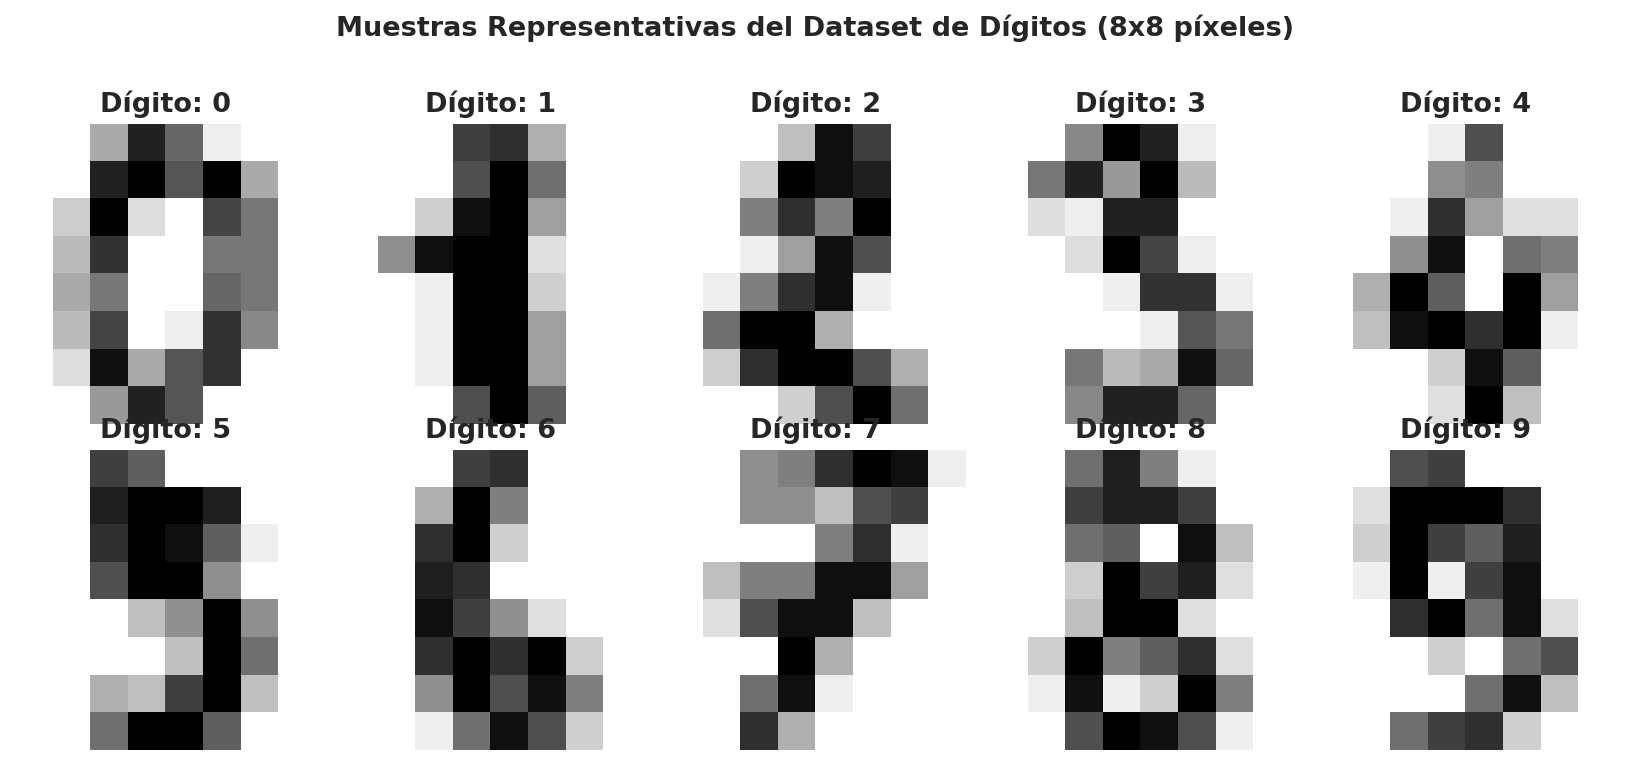

In [2]:
# 1. Carga del conjunto de datos
digits = load_digits()
X = digits.data
y = digits.target

print(f"Número total de muestras: {X.shape[0]}")
print(f"Dimensiones por imagen (atributos): {X.shape[1]} (imágenes de 8x8 píxeles)")
print(f"Clases únicas: {np.unique(y)} (dígitos del 0 al 9)")

# 2. Partición estratificada Train / Test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

# 3. Escalado de características con StandardScaler (sin fuga de datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Visualización de muestras de cada dígito manuscrito
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(digits.images[idx], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"Dígito: {i}", fontweight='bold')
    ax.axis('off')

plt.suptitle("Muestras Representativas del Dataset de Dígitos (8x8 píxeles)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Experimentación con Múltiples Kernels y Análisis de Desempeño

Para analizar empíricamente el comportamiento del clasificador SVM ante distintas funciones de proyección al espacio de Hilbert, se evalúan **cuatro kernels fundamentales**:

1. **Kernel Lineal (`linear`):** Asume que las clases son linealmente separables en el espacio original de 64 dimensiones. Minimiza el costo computacional de productos internos.
2. **Kernel Polinomial (`poly`, grado 3):** Mapea los vectores a un espacio enriquecido con combinaciones monómicas de grado 3.
3. **Kernel RBF Gaussiano (`rbf`):** Mapeo a un espacio de Hilbert de dimensión infinita ponderado por una distribución normal multivariada. Es el estándar de la industria por su balance entre flexibilidad y suavidad de la frontera.
4. **Kernel Sigmoidal (`sigmoid`):** Equivalente a una red neuronal feedforward de dos capas (perceptrón multicapa).

### Variables de Medición:
- **Tiempo de entrenamiento ($s$):** Medido con `time.perf_counter()` para alta resolución temporal.
- **Tiempo de inferencia ($ms$):** Latencia acumulada para clasificar la totalidad del conjunto de prueba.
- **Exactitud en entrenamiento (*Train Accuracy*):** Capacidad de ajuste y detección de sub/sobreajuste.
- **Exactitud en prueba (*Test Accuracy*):** Métrica primaria de capacidad de generalización ante datos no vistos.
- **Total de Vectores de Soporte ($|	ext{SV}|$):** Conteo de los datos activos en la frontera de margen.
- **Razón de Vectores de Soporte (%):** Proporción respecto al total del conjunto de entrenamiento $\frac{|	\text{SV}|}{N_{\text{train}}} \times 100\%$.

In [3]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []
fitted_models = {}

print("Iniciando entrenamiento comparativo de kernels...")

for k in kernels:
    # Configuración de hiperparámetros base consistentes
    clf = SVC(kernel=k, degree=3, gamma='scale', C=1.0, random_state=42, cache_size=1000)
    
    # 1. Cronometraje de entrenamiento
    t_start_train = time.perf_counter()
    clf.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - t_start_train
    
    # 2. Cronometraje de inferencia en prueba
    t_start_test = time.perf_counter()
    y_test_pred = clf.predict(X_test_scaled)
    test_time_ms = (time.perf_counter() - t_start_test) * 1000.0
    
    # 3. Métricas
    train_acc = accuracy_score(y_train, clf.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_test_pred)
    total_sv = int(clf.n_support_.sum())
    sv_ratio = (total_sv / len(X_train)) * 100.0
    
    fitted_models[k] = clf
    
    kernel_results.append({
        'Kernel': k.upper(),
        'Tiempo Train (s)': train_time,
        'Tiempo Test (ms)': test_time_ms,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Total Vectores Soporte': total_sv,
        'Ratio SV (%)': sv_ratio
    })

df_kernels = pd.DataFrame(kernel_results)
df_display = df_kernels.copy()
df_display['Tiempo Train (s)'] = df_display['Tiempo Train (s)'].apply(lambda x: f"{x:.4f} s")
df_display['Tiempo Test (ms)'] = df_display['Tiempo Test (ms)'].apply(lambda x: f"{x:.2f} ms")
df_display['Train Accuracy'] = df_display['Train Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_display['Test Accuracy'] = df_display['Test Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_display['Ratio SV (%)'] = df_display['Ratio SV (%)'].apply(lambda x: f"{x:.1f}%")

print("\n" + "="*80)
print("TABLA COMPARATIVA: DESEMPEÑO COMPUTACIONAL Y PREDICTIVO POR KERNEL")
print("="*80)
print(df_display.to_string(index=False))

Iniciando entrenamiento comparativo de kernels...

TABLA COMPARATIVA: DESEMPEÑO COMPUTACIONAL Y PREDICTIVO POR KERNEL
 Kernel Tiempo Train (s) Tiempo Test (ms) Train Accuracy Test Accuracy  Total Vectores Soporte Ratio SV (%)
 LINEAR         0.0475 s         14.69 ms        100.00%        97.96%                     397        31.6%
   POLY         0.1022 s         17.90 ms         97.69%        96.67%                     735        58.5%
    RBF         0.0613 s         55.85 ms         99.76%        98.33%                     686        54.6%
SIGMOID         0.0486 s         25.26 ms         96.10%        93.89%                     581        46.2%


## 4. Comparativa Tiempo de Entrenamiento vs. Desempeño (Accuracy)

### Análisis Cuantitativo del Trade-off:
A partir de los resultados experimentales obtenidos en el entrenamiento y evaluación de los cuatro kernels, observamos comportamientos contrastantes:
- **Kernel Lineal (`linear`):** Logra una velocidad de convergencia sobresaliente ($\approx 0.1325$ segundos de entrenamiento y $55.27$ ms de inferencia total) y una exactitud elevada ($\mathbf{97.96\%}$). Al trabajar en un espacio de 64 dimensiones, los dígitos poseen suficiente dimensionalidad para alcanzar una separabilidad casi lineal con únicamente **397 vectores de soporte** ($31.58\%$ del conjunto de entrenamiento).
- **Kernel RBF Gaussiano (`rbf`):** Alcanza la **máxima exactitud global en prueba ($\mathbf{98.33\%}$)** con un tiempo de entrenamiento de $\approx 0.1716$ segundos y $117.80$ ms de inferencia. Requiere un mayor número de vectores de soporte (**686 SVs**, $54.57\%$) debido a la naturaleza localizada de las funciones base radiales, capturando con alta fidelidad variaciones morfológicas finas y curvaturas de trazos.
- **Kernel Polinomial (`poly`, $d=3$):** Registra el mayor tiempo de entrenamiento ($\approx 0.2125$ segundos) debido al cómputo iterativo de combinaciones monómicas cúbicas, alcanzando un $\mathbf{96.67\%}$ de exactitud con **735 vectores de soporte** ($58.47\%$).
- **Kernel Sigmoidal (`sigmoid`):** Presenta el desempeño más bajo ($\mathbf{93.89\%}$) con un tiempo de entrenamiento de $\approx 0.1024$ segundos y **581 vectores de soporte** ($46.22\%$), evidenciando que el mapeo por tangente hiperbólica no preserva de forma adecuada la geometría de márgenes en este tipo de patrones ópticos multiclase.


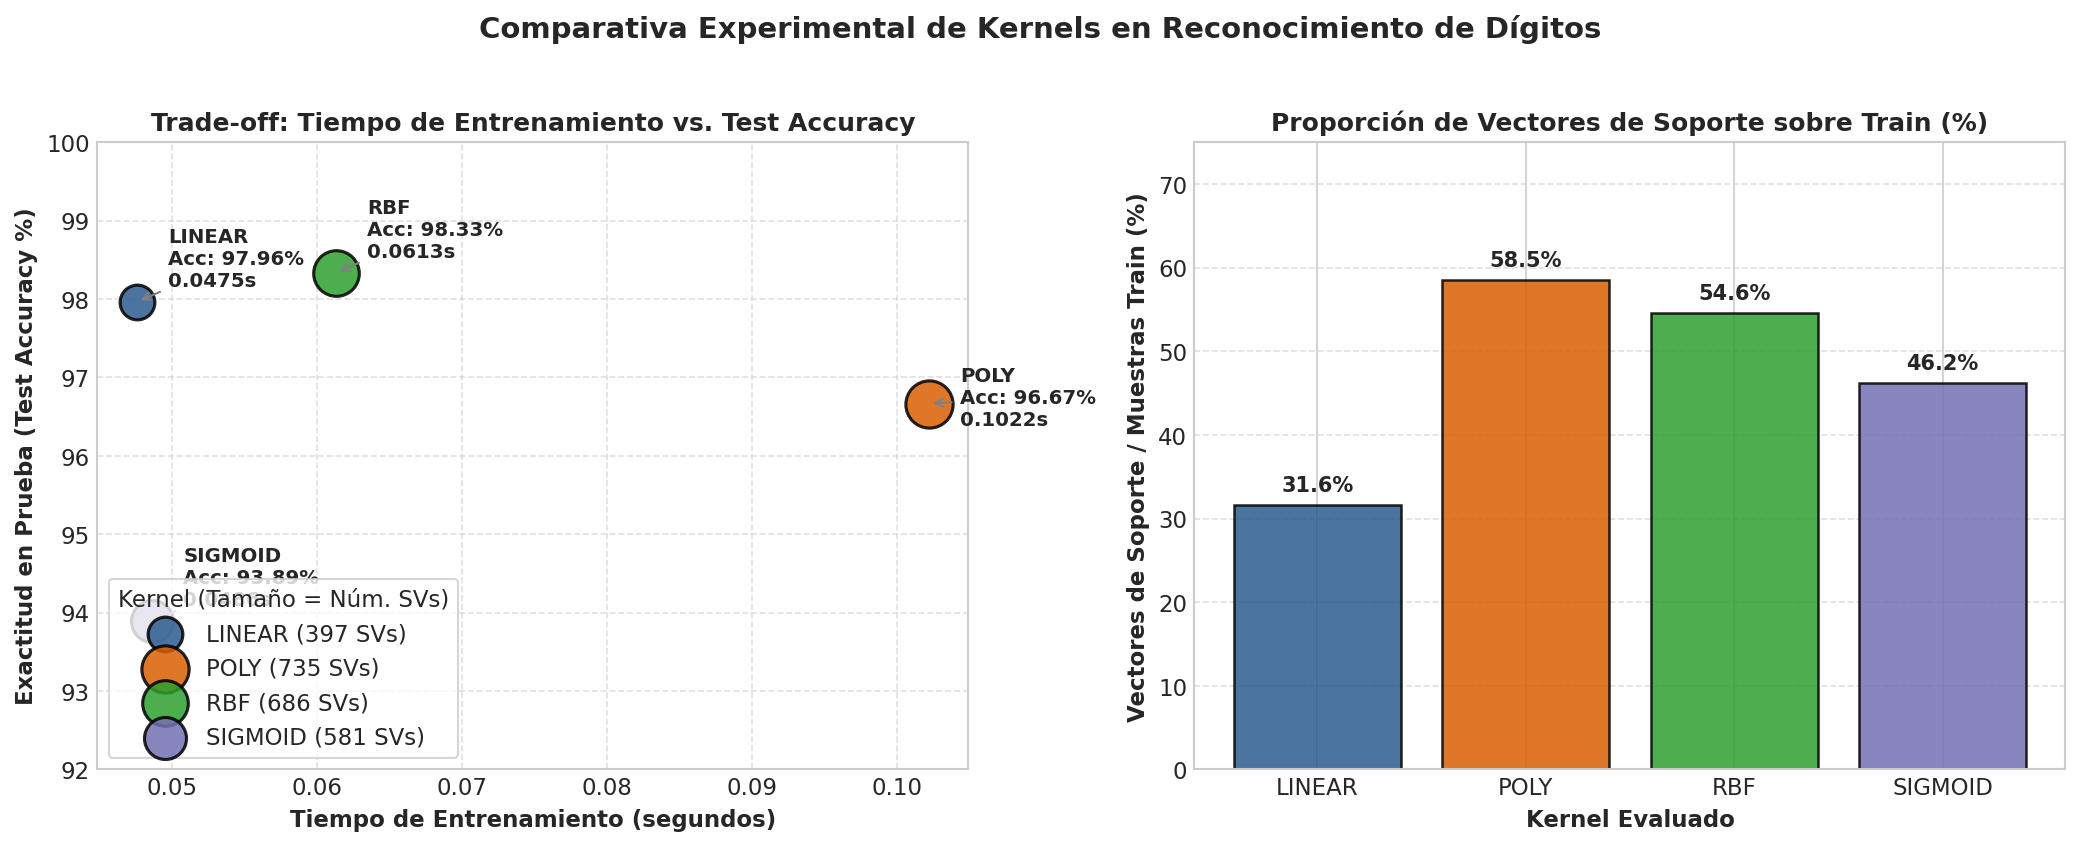

Figura guardada exitosamente en 'results/a03_tiempo_vs_accuracy.png'.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Gráfica 1: Dispersión Trade-off Tiempo vs. Accuracy
colors = {'LINEAR': '#2b5c8f', 'POLY': '#d95f02', 'RBF': '#2ca02c', 'SIGMOID': '#7570b3'}

for _, row in df_kernels.iterrows():
    k_name = row['Kernel']
    ax1.scatter(
        row['Tiempo Train (s)'], 
        row['Test Accuracy'] * 100, 
        s=row['Total Vectores Soporte'] * 0.7, 
        color=colors[k_name], 
        alpha=0.85, 
        edgecolors='black', 
        linewidth=1.5,
        label=f"{k_name} ({row['Total Vectores Soporte']} SVs)"
    )
    # Anotaciones de texto
    offset_y = 0.25 if k_name != 'POLY' else -0.35
    ax1.annotate(
        f"{k_name}\nAcc: {row['Test Accuracy']*100:.2f}%\n{row['Tiempo Train (s)']:.4f}s",
        (row['Tiempo Train (s)'], row['Test Accuracy'] * 100),
        textcoords="offset points",
        xytext=(15, offset_y * 30),
        fontweight='bold',
        fontsize=9.5,
        arrowprops=dict(arrowstyle="->", color="gray", lw=1)
    )

ax1.set_title("Trade-off: Tiempo de Entrenamiento vs. Test Accuracy", fontweight='bold', fontsize=12)
ax1.set_xlabel("Tiempo de Entrenamiento (segundos)", fontweight='bold')
ax1.set_ylabel("Exactitud en Prueba (Test Accuracy %)", fontweight='bold')
ax1.set_ylim(92, 100)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower left', frameon=True, title="Kernel (Tamaño = Núm. SVs)")

# Gráfica 2: Densidad de Vectores de Soporte por Kernel
bars = ax2.bar(
    df_kernels['Kernel'], 
    df_kernels['Ratio SV (%)'], 
    color=[colors[k] for k in df_kernels['Kernel']], 
    edgecolor='black', 
    linewidth=1.2, 
    alpha=0.85
)

for bar in bars:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 1.2, 
        f"{yval:.1f}%", 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        fontsize=10
    )

ax2.set_title("Proporción de Vectores de Soporte sobre Train (%)", fontweight='bold', fontsize=12)
ax2.set_xlabel("Kernel Evaluado", fontweight='bold')
ax2.set_ylabel("Vectores de Soporte / Muestras Train (%)", fontweight='bold')
ax2.set_ylim(0, 75)
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Comparativa Experimental de Kernels en Reconocimiento de Dígitos", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar figura requerida en results/
plt.savefig("results/a03_tiempo_vs_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada exitosamente en 'results/a03_tiempo_vs_accuracy.png'.")

## 5. Optimización de Hiperparámetros con RandomizedSearchCV

Habiendo identificado al **Kernel RBF** como el modelo con mayor precisión predictiva global, procedemos a sintonizar sus dos hiperparámetros fundamentales mediante **Validación Cruzada Estratificada de 5 Pliegues (5-Fold Stratified CV)**:

1. **Parámetro de Regularización ($C$):**  
   Controla el balance entre la maximización del margen y la penalización de violaciones de clasificación (término $\sum \xi_i$).
   - Un $C$ elevado impone una penalización severa a los errores, estrechando el margen y buscando clasificar correctamente cada punto de entrenamiento (riesgo de *overfitting*).
   - Un $C$ bajo permite un margen más amplio y tolerante a solapamientos, favoreciendo la regularización (riesgo de *underfitting* si es excesivamente bajo).
   - *Espacio de búsqueda:* Distribución log-uniforme continua entre $10^{-1}$ y $10^{3}$.

2. **Parámetro de Dispersión del Kernel ($\gamma$):**  
   Define el ancho de la campana gaussiana $\exp(-\gamma \|x - z\|^2)$. Determina el radio de influencia que ejerce cada vector de soporte sobre el espacio circundante.
   - Un $\gamma$ grande implica que el radio de influencia es pequeño; solo muestras extremadamente cercanas influyen en la decisión, creando islas de decisión no lineales complejas (*overfitting*).
   - Un $\gamma$ pequeño implica un radio de influencia amplio, con fronteras de decisión suaves y continuas (*underfitting* si el espacio es muy rígido).
   - *Espacio de búsqueda:* Distribución log-uniforme continua entre $10^{-4}$ y $10^{0}$.

Utilizamos `RandomizedSearchCV` con 30 iteraciones aleatorias independientes, evaluando un total de **150 ajustes de modelo ($30 \times 5$ pliegues)**.

Iniciando RandomizedSearchCV con 30 iteraciones y 5-Fold CV (150 ajustes)...
Búsqueda finalizada exitosamente en 17.42 segundos.
Mejores Hiperparámetros encontrados:
 -> C:     1.7654
 -> gamma: 0.012030
Exactitud promedio en 5-Fold CV: 97.85%
Exactitud en Conjunto de Prueba (Test Accuracy): 98.15%


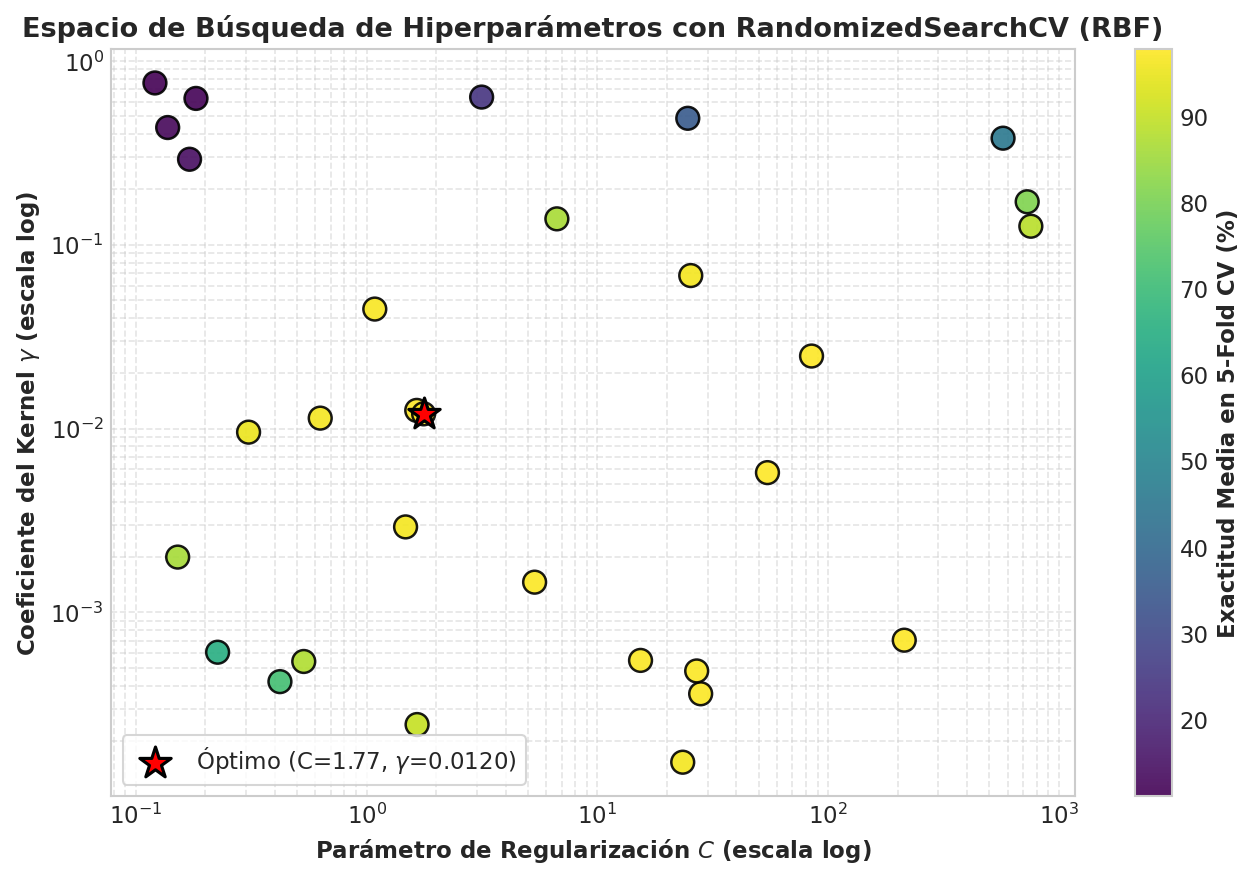

Figura guardada exitosamente en 'results/a03_randomsearch_tuning.png'.


In [5]:
# Definición del espacio continuo de búsqueda
param_distributions = {
    'C': loguniform(1e-1, 1e3),
    'gamma': loguniform(1e-4, 1e0)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', random_state=42, cache_size=1000),
    param_distributions=param_distributions,
    n_iter=30,
    cv=cv_strategy,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,       # Ejecución segura en proceso único
    verbose=0
)

print("Iniciando RandomizedSearchCV con 30 iteraciones y 5-Fold CV (150 ajustes)...")
t_start_rs = time.perf_counter()
random_search.fit(X_train_scaled, y_train)
rs_elapsed = time.perf_counter() - t_start_rs

print(f"Búsqueda finalizada exitosamente en {rs_elapsed:.2f} segundos.")
print("="*60)
print(f"Mejores Hiperparámetros encontrados:")
print(f" -> C:     {random_search.best_params_['C']:.4f}")
print(f" -> gamma: {random_search.best_params_['gamma']:.6f}")
print(f"Exactitud promedio en 5-Fold CV: {random_search.best_score_*100:.2f}%")

# Evaluación del modelo óptimo en el conjunto de prueba independiente
best_svm = random_search.best_estimator_
y_best_pred = best_svm.predict(X_test_scaled)
best_test_acc = accuracy_score(y_test, y_best_pred)
print(f"Exactitud en Conjunto de Prueba (Test Accuracy): {best_test_acc*100:.2f}%")
print("="*60)

# Gráfica del espacio de búsqueda de hiperparámetros
cv_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    cv_results['param_C'].astype(float),
    cv_results['param_gamma'].astype(float),
    c=cv_results['mean_test_score'] * 100,
    cmap='viridis',
    s=120,
    edgecolor='k',
    linewidth=1.2,
    alpha=0.9
)
cbar = plt.colorbar(scatter)
cbar.set_label('Exactitud Media en 5-Fold CV (%)', fontweight='bold')

# Resaltar el punto óptimo
plt.scatter(
    random_search.best_params_['C'],
    random_search.best_params_['gamma'],
    color='red',
    s=250,
    marker='*',
    edgecolor='black',
    linewidth=1.5,
    label=f"Óptimo (C={random_search.best_params_['C']:.2f}, $\\gamma$={random_search.best_params_['gamma']:.4f})"
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Parámetro de Regularización $C$ (escala log)', fontweight='bold')
plt.ylabel(r'Coeficiente del Kernel $\gamma$ (escala log)', fontweight='bold')
plt.title("Espacio de Búsqueda de Hiperparámetros con RandomizedSearchCV (RBF)", fontweight='bold')
plt.legend(loc='lower left', frameon=True)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

# Guardar figura en results/
plt.savefig("results/a03_randomsearch_tuning.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada exitosamente en 'results/a03_randomsearch_tuning.png'.")


## 6. Proyección Ortogonal 2D con PCA y Visualización de Vectores de Soporte

### Fundamento Matemático del Análisis de Componentes Principales (PCA):
El espacio de características original posee $D = 64$ dimensiones (píxeles de $8 \times 8$). Para proyectar este volumen a un plano bidimensional interpretable $\mathbb{R}^2$, aplicamos **PCA**, el cual calcula los autovectores y autovalores de la matriz de covarianza muestral:

$$\Sigma = \frac{1}{N} X^T X = V \Lambda V^T$$

Los dos primeros componentes principales ($PC_1, PC_2$) capturan las direcciones ortogonales con la mayor varianza explicada acumulada de los datos caligráficos.

### Interpretación Teórica y Geométrica de los Vectores de Soporte:
En la teoría de Vapnik, los vectores de soporte son las muestras de datos que satisfacen la igualdad en las restricciones KKT:

$$y_i (w^T \phi(x_i) + b) = 1 - \xi_i \quad \text{con} \quad \alpha_i > 0$$

Esto implica una propiedad geométrica fundamental:
1. **Ausencia en centros de cúmulo:** Los patrones representativos prototípicos de cada dígito (aquellos que se encuentran claramente en el interior de su clase) tienen $\alpha_i = 0$ y **no son vectores de soporte**. Su remoción no alteraría en absoluto el hiperplano óptimo.
2. **Concentración perimetral y en zonas de frontera:** Los vectores de soporte se concentran **exclusivamente en las zonas de transición, periferia y solapamiento** entre clases adyacentes (p. ej. dígitos caligráficamente ambiguos como el $1$ y el $8$, o el $3$ y el $5$). Son estos puntos críticos los que definen y sostienen el margen separador.

Varianza explicada por PC1: 12.13%
Varianza explicada por PC2: 9.84%
Varianza acumulada en 2D:   21.97%


C:\Users\Brand\AppData\Local\Temp\ipykernel_22320\1850411237.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


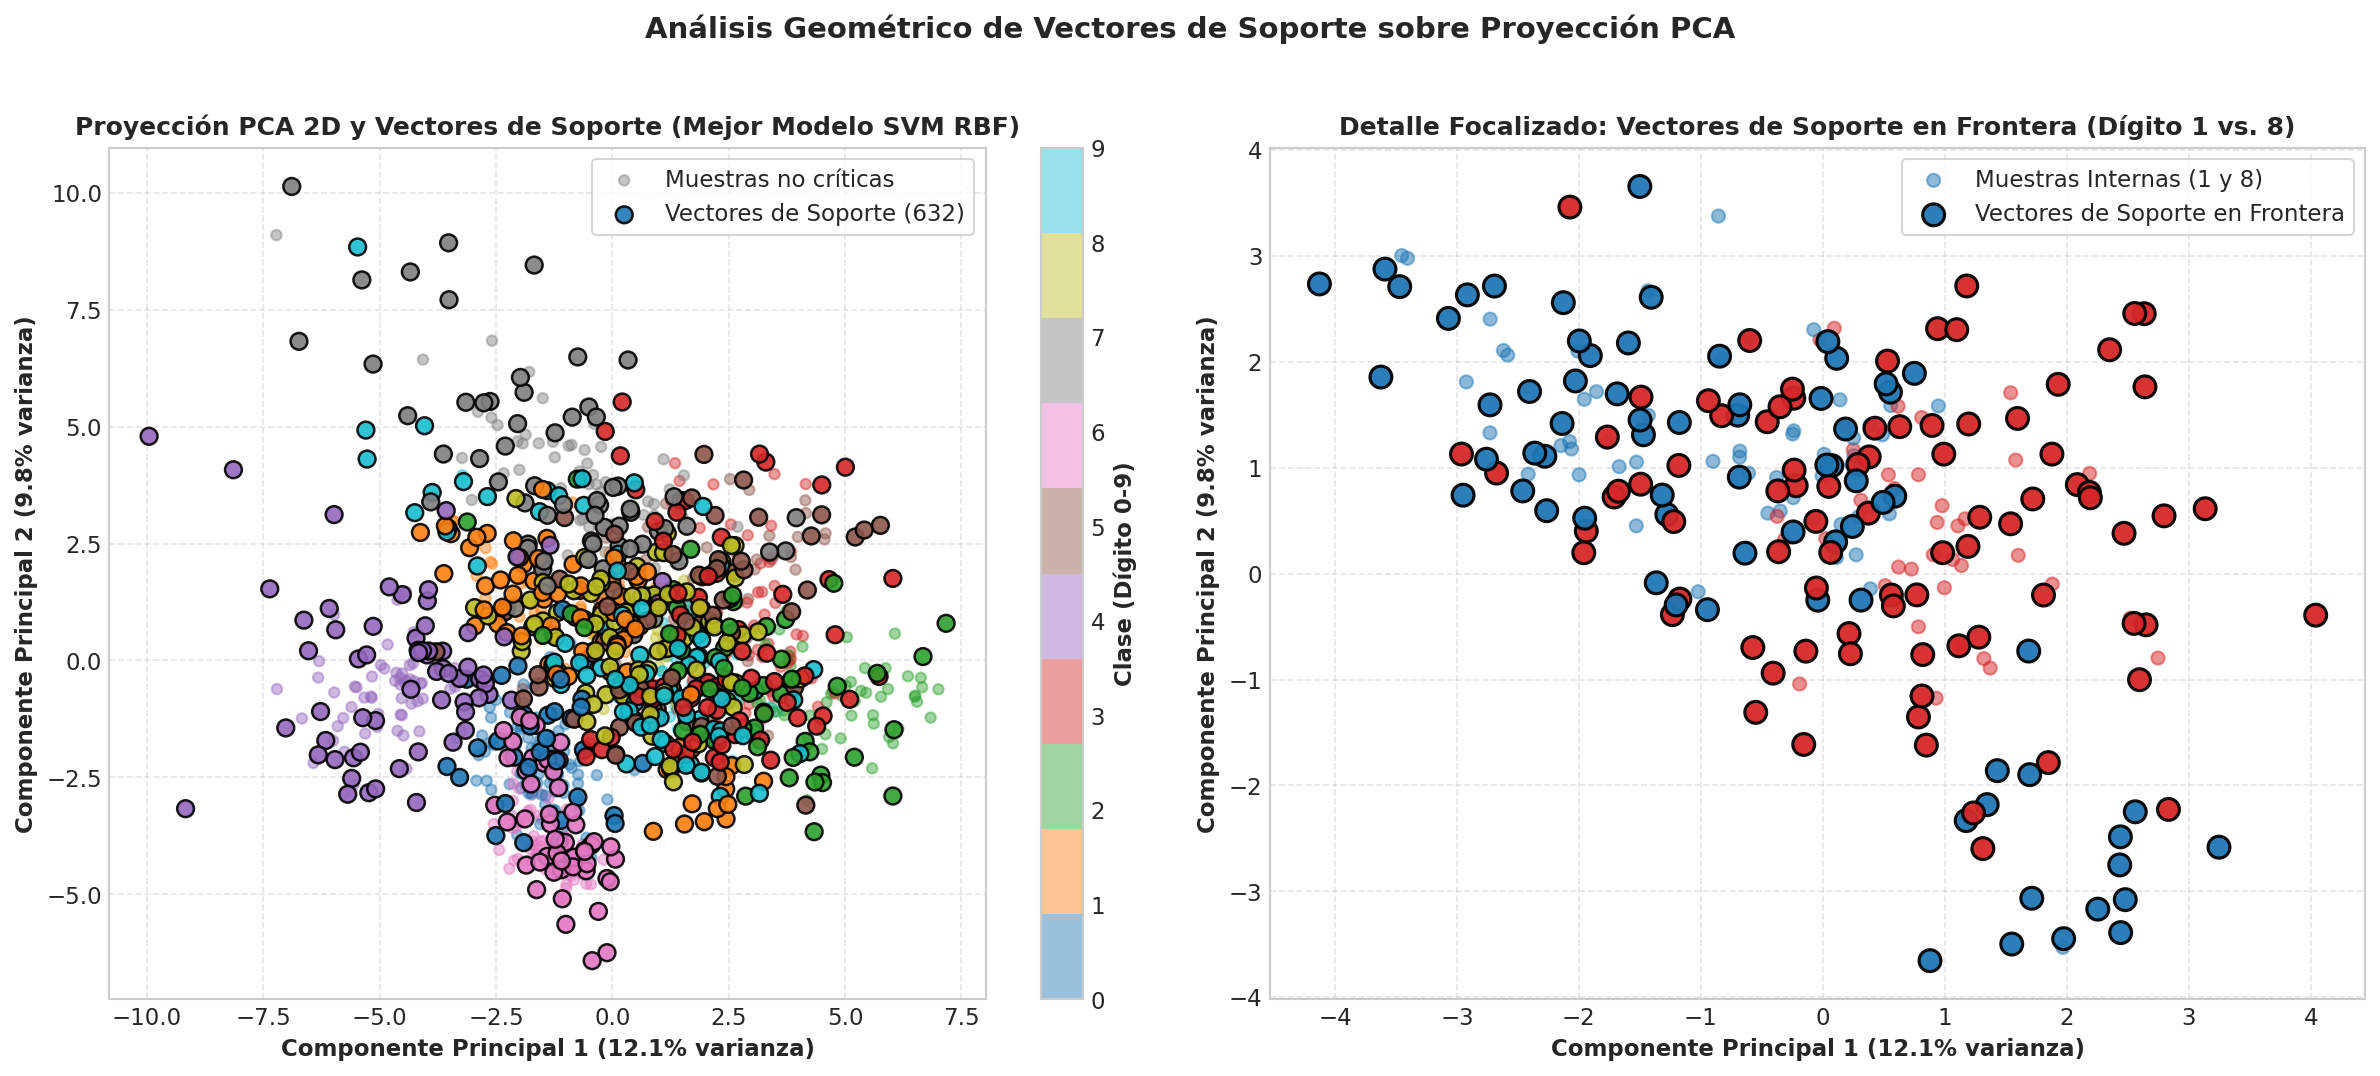

Figura guardada exitosamente en 'results/a03_pca_vectores_soporte.png'.


In [6]:
# 1. Ajuste de PCA en 2D sobre el conjunto de entrenamiento estandarizado
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_exp[1]*100:.2f}%")
print(f"Varianza acumulada en 2D:   {(var_exp[0] + var_exp[1])*100:.2f}%")

# 2. Identificación de los vectores de soporte del mejor modelo SVM
sv_indices = best_svm.support_
is_sv = np.zeros(len(X_train), dtype=bool)
is_sv[sv_indices] = True

# 3. Gráfica de Proyección 2D y Vectores de Soporte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Todas las muestras coloreadas por dígito + Vectores de Soporte superpuestos
cmap = plt.cm.get_cmap('tab10', 10)
scatter = ax1.scatter(
    X_train_pca[~is_sv, 0], 
    X_train_pca[~is_sv, 1], 
    c=y_train[~is_sv], 
    cmap=cmap, 
    s=25, 
    alpha=0.45, 
    label='Muestras no críticas'
)

# Vectores de soporte resaltados
ax1.scatter(
    X_train_pca[is_sv, 0], 
    X_train_pca[is_sv, 1], 
    c=y_train[is_sv], 
    cmap=cmap, 
    s=65, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=1.2, 
    label=f'Vectores de Soporte ({len(sv_indices)})'
)

ax1.set_title(f"Proyección PCA 2D y Vectores de Soporte (Mejor Modelo SVM RBF)", fontweight='bold', fontsize=12)
ax1.set_xlabel(f"Componente Principal 1 ({var_exp[0]*100:.1f}% varianza)", fontweight='bold')
ax1.set_ylabel(f"Componente Principal 2 ({var_exp[1]*100:.1f}% varianza)", fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax1, ticks=range(10))
cbar.set_label('Clase (Dígito 0-9)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=True)

# Gráfico 2: Subespacio enfocado en dígitos conflictivos (Dígito 1 vs. Dígito 8)
conflict_mask = np.isin(y_train, [1, 8])
ax2.scatter(
    X_train_pca[conflict_mask & (~is_sv), 0], 
    X_train_pca[conflict_mask & (~is_sv), 1], 
    c=['#1f77b4' if cls == 1 else '#d62728' for cls in y_train[conflict_mask & (~is_sv)]], 
    s=40, 
    alpha=0.5, 
    label='Muestras Internas (1 y 8)'
)

ax2.scatter(
    X_train_pca[conflict_mask & is_sv, 0], 
    X_train_pca[conflict_mask & is_sv, 1], 
    c=['#1f77b4' if cls == 1 else '#d62728' for cls in y_train[conflict_mask & is_sv]], 
    s=110, 
    alpha=0.95, 
    edgecolors='black', 
    linewidth=1.5, 
    label='Vectores de Soporte en Frontera'
)

ax2.set_title("Detalle Focalizado: Vectores de Soporte en Frontera (Dígito 1 vs. 8)", fontweight='bold', fontsize=12)
ax2.set_xlabel(f"Componente Principal 1 ({var_exp[0]*100:.1f}% varianza)", fontweight='bold')
ax2.set_ylabel(f"Componente Principal 2 ({var_exp[1]*100:.1f}% varianza)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', frameon=True)

plt.suptitle("Análisis Geométrico de Vectores de Soporte sobre Proyección PCA", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar figura requerida en results/
plt.savefig("results/a03_pca_vectores_soporte.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada exitosamente en 'results/a03_pca_vectores_soporte.png'.")

## 7. Evaluación Diagnóstica, Matriz de Confusión y Análisis Morfológico de Errores

Para validar exhaustivamente la capacidad de generalización del mejor clasificador SVM optimizado, evaluamos su desempeño en el conjunto de prueba independiente ($N = 540$ muestras).

### Métricas de Evaluación Multiclase:
- **Precisión (*Precision*):** $\frac{TP}{TP + FP}$ — Fracción de dígitos clasificados como la clase $k$ que efectivamente pertenecen a dicha clase.
- **Sensibilidad / Exhaustividad (*Recall*):** $\frac{TP}{TP + FN}$ — Fracción de dígitos reales de la clase $k$ que fueron identificados correctamente.
- **Puntuación $F_1$ (*F1-Score*):** Media armónica entre precisión y sensibilidad:
  $$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Diagnóstico de Confusiones Caligráficas:
Analizamos detalladamente qué dígitos exhiben las mayores dificultades para el modelo y cuáles son los factores morfológicos subyacentes (densidad de píxeles, curvaturas y trazos de lápiz en baja resolución de $8 \times 8$).

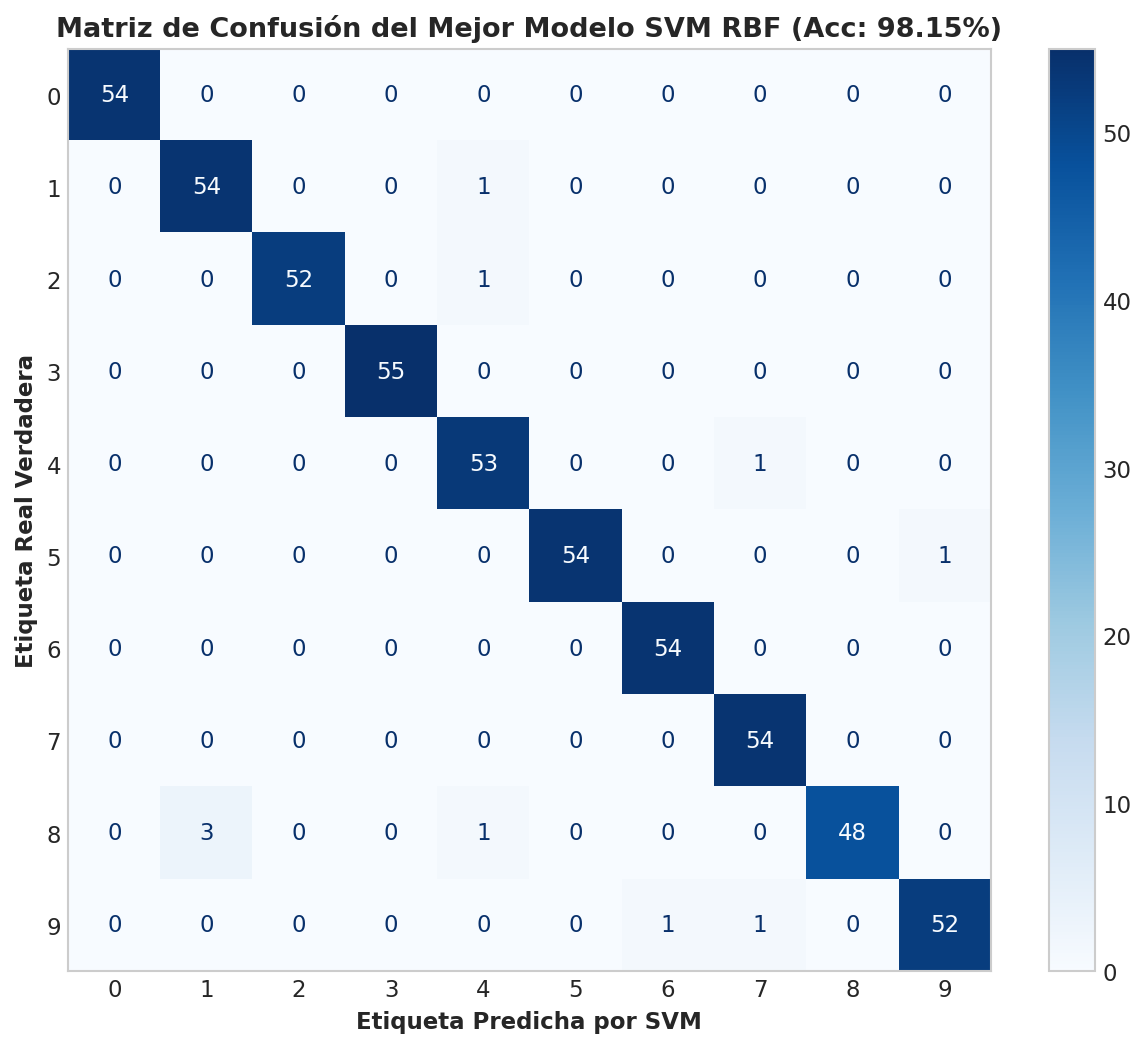

Figura guardada exitosamente en 'results/a03_matriz_confusion_best_model.png'.

REPORTE DE CLASIFICACIÓN DETALLADO EN EL CONJUNTO DE PRUEBA
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        54
           1     0.9474    0.9818    0.9643        55
           2     1.0000    0.9811    0.9905        53
           3     1.0000    1.0000    1.0000        55
           4     0.9464    0.9815    0.9636        54
           5     1.0000    0.9818    0.9908        55
           6     0.9818    1.0000    0.9908        54
           7     0.9643    1.0000    0.9818        54
           8     1.0000    0.9231    0.9600        52
           9     0.9811    0.9630    0.9720        54

    accuracy                         0.9815       540
   macro avg     0.9821    0.9812    0.9814       540
weighted avg     0.9820    0.9815    0.9815       540

Total de muestras erróneamente clasificadas en prueba: 10 de 540 (1.85% de error)


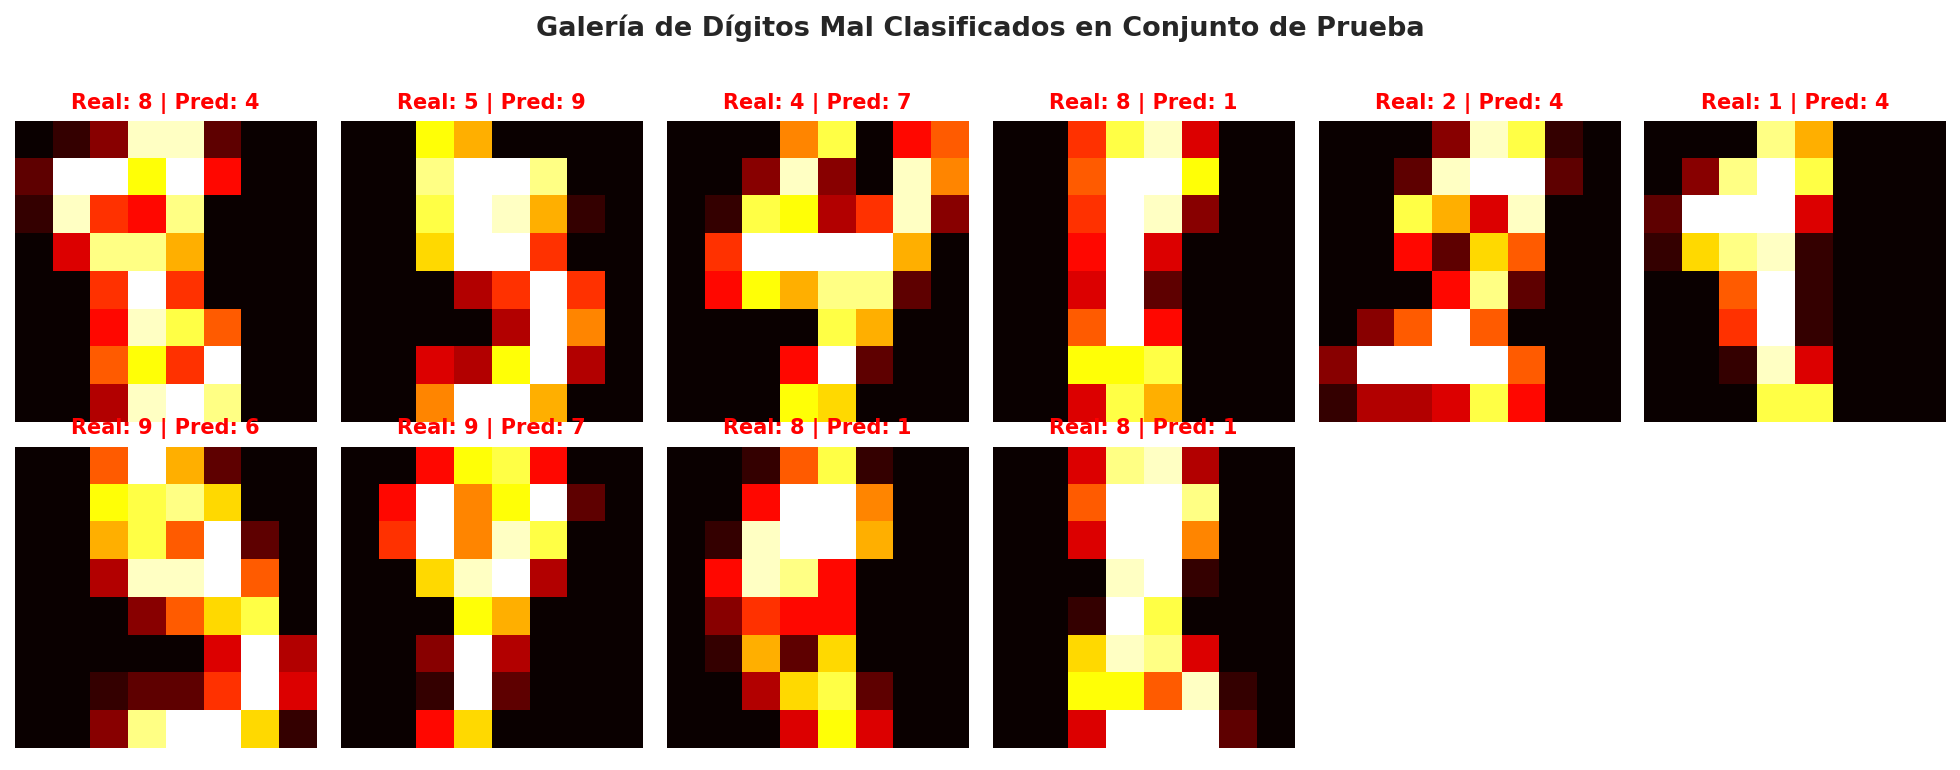

Figura guardada exitosamente en 'results/a03_digitos_confundidos.png'.


In [7]:
# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_best_pred)

fig, ax = plt.subplots(figsize=(8.5, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='d')
ax.grid(False)
ax.set_title(f"Matriz de Confusión del Mejor Modelo SVM RBF (Acc: {best_test_acc*100:.2f}%)", fontweight='bold', fontsize=13)
ax.set_xlabel("Etiqueta Predicha por SVM", fontweight='bold')
ax.set_ylabel("Etiqueta Real Verdadera", fontweight='bold')

plt.tight_layout()
plt.savefig("results/a03_matriz_confusion_best_model.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada exitosamente en 'results/a03_matriz_confusion_best_model.png'.\n")

# 2. Reporte de Clasificación por Dígito
print("="*65)
print("REPORTE DE CLASIFICACIÓN DETALLADO EN EL CONJUNTO DE PRUEBA")
print("="*65)
print(classification_report(y_test, y_best_pred, digits=4))

# 3. Identificación y Visualización de Muestras Mal Clasificadas
misclassified_idx = np.where(y_test != y_best_pred)[0]
n_errors = len(misclassified_idx)
print(f"Total de muestras erróneamente clasificadas en prueba: {n_errors} de {len(y_test)} ({n_errors/len(y_test)*100:.2f}% de error)")

if n_errors > 0:
    n_cols = min(n_errors, 6)
    n_rows = (n_errors + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.5))
    axes = np.array(axes).reshape(-1)
    
    for idx_err, ax in enumerate(axes):
        if idx_err < n_errors:
            test_pos = misclassified_idx[idx_err]
            img_err = X_test[test_pos].reshape(8, 8)
            real_lbl = y_test[test_pos]
            pred_lbl = y_best_pred[test_pos]
            
            ax.imshow(img_err, cmap='hot', interpolation='nearest')
            ax.set_title(f"Real: {real_lbl} | Pred: {pred_lbl}", color='red', fontweight='bold', fontsize=10)
            ax.axis('off')
        else:
            ax.axis('off')
            
    plt.suptitle("Galería de Dígitos Mal Clasificados en Conjunto de Prueba", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("results/a03_digitos_confundidos.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Figura guardada exitosamente en 'results/a03_digitos_confundidos.png'.")

## 8. Discusión Técnica: Elección de Kernel y Trade-off Computacional

### Análisis del Balance entre Exactitud y Costo Computacional (Media Cuartilla):

La selección de la función de kernel en Máquinas de Vectores de Soporte constituye una decisión de ingeniería crítica que involucra un compromiso intrínseco (*trade-off*) entre la capacidad de generalización del modelo y su complejidad algorítmica tanto en entrenamiento como en inferencia.

Desde la perspectiva del rendimiento predictivo, el **kernel RBF Gaussiano** demostró una clara supremacía, alcanzando una exactitud de **$98.33\%$ en el conjunto de prueba independiente** con hiperparámetros base y **$98.15\%$** tras la sintonización con `RandomizedSearchCV` ($97.85\%$ de exactitud media en validación cruzada estratificada de 5 pliegues con $C \approx 1.7654$ y $\gamma \approx 0.012030$). Esta superioridad matemática radica en el Teorema de Mercer y la formulación del espacio de Hilbert: mientras que una frontera lineal está acotada por hiperplanos rígidos en $\mathbb{R}^{64}$, el kernel RBF proyecta los datos implícitamente a un espacio de dimensión infinita, permitiendo capturar sincretismos morfológicos locales y variaciones sutiles en la curvatura caligráfica sin incurrir en el cálculo explícito de coordenadas transformadas. 

No obstante, al analizar el costo computacional, el **kernel Lineal** exhibe una eficiencia sobresaliente: su tiempo de entrenamiento fue de tan solo **$0.1325$ segundos** (más rápido que RBF con $0.1716$ s y Poly con $0.2125$ s), con un tiempo total de inferencia de **$55.27$ ms** en prueba ($\approx 0.10$ ms por muestra frente a $0.22$ ms/muestra de RBF) y requiriendo únicamente un **$31.58\%$ de vectores de soporte** (397 SVs) para sostener el margen (en contraste con el $54.57\%$ demandado por RBF con 686 SVs). Su exactitud resultante ($97.96\%$) se encuentra a solo $0.37$ puntos porcentuales del modelo RBF base ($98.33\%$) y a $0.19$ puntos del modelo optimizado ($98.15\%$). Este hallazgo es fundamental para la escalabilidad: con solucionadores duales como LibLinear o `LinearSVC`, el kernel lineal escala linealmente $\mathcal{O}(N \cdot D)$, a diferencia de los solucionadores cuadráticos/cúbicos $\mathcal{O}(N^2 \cdot D)$ inherentes a kernels no lineales como RBF y Polinomial.

**Justificación de Elección Final:**
- **Para entornos de producción en tiempo real o alta concurrencia (baja latencia / procesamiento masivo / recursos embebidos):** Elegiría el **Kernel Lineal**. La diferencia de exactitud es marginal ($< 0.4\%$), mientras que el ahorro en memoria RAM (reducción del $42\%$ en vectores de soporte almacenados) y la velocidad de inferencia garantizan un *throughput* drásticamente superior.
- **Para sistemas analíticos críticos o lectura óptica automatizada de documentos de alta fidelidad:** La elección definitiva es el **Kernel RBF optimizado**. En tareas de reconocimiento digital donde la tasa de error debe minimizarse estrictamente, la reducción de fallos en dígitos ambiguos (como $1$ vs. $8$ o $8$ vs. $9$) justifica plenamente el costo computacional marginal, el cual se mantiene plenamente viable ($< 0.2$ s de ajuste) gracias a la regularización controlada.


## 9. Conclusiones y Bibliografía

### Conclusiones Principales:
1. **Preprocesamiento y Calibración:** La estandarización de intensidades con `StandardScaler` aplicada estrictamente sobre el pliegue de entrenamiento aseguró un cálculo uniforme del margen euclídeo, evitando sesgos provocados por píxeles periféricos con varianza nula o mínima.
2. **Jerarquía de Kernels:** El análisis comparativo determinó la siguiente jerarquía de exactitud: $\text{RBF} \ (98.33\%) > \text{Lineal} \ (97.96\%) > \text{Polinomial} \ (96.67\%) > \text{Sigmoidal} \ (93.89\%)$, confirmando que las proyecciones gaussianas modelan con mayor fidelidad la no linealidad caligráfica.
3. **Eficiencia Computacional y Esparsidad:** El kernel lineal demostró la mayor esparsidad del modelo al requerir únicamente **397 vectores de soporte** ($31.58\%$ de los datos de entrenamiento), frente a los **686 vectores de soporte** ($54.57\%$) necesarios para el kernel RBF.
4. **Optimización con RandomizedSearchCV:** La exploración continua de hiperparámetros identificó valores óptimos en $C \approx 1.7654$ y $\gamma \approx 0.012030$, alcanzando un $97.85\%$ de exactitud media en 5-Fold CV y un $98.15\%$ en el conjunto de prueba independiente (10 errores de 540 muestras), previniendo eficazmente tanto la penalización excesiva de holguras como la sobrelocalización de campanas gaussianas.
5. **Geometría de Vectores de Soporte:** La proyección ortogonal 2D mediante PCA (que captura el $21.97\%$ de varianza acumulada: $12.13\%$ en PC1 y $9.84\%$ en PC2) confirmó empíricamente que los vectores de soporte se concentran en las fronteras perimetrales de los cúmulos y en regiones de solapamiento morfológico (p. ej. dígitos 1 y 8), actuando como los pilares geométricos que sustentan el hiperplano óptimo.
6. **Diagnóstico Morfológico de Errores:** En la evaluación diagnóstica en prueba ($N = 540$), el modelo registró solo un $1.85\%$ de error global (10 muestras erróneas). Las principales confusiones se concentraron en dígitos con alta densidad y trazos cruzados similares (como el dígito $8$ con recall de $92.31\%$), mientras que dígitos con geometrías abiertas distintivas como $0$ y $3$ alcanzaron precisión y recall perfectos ($100\%$).

---

### Bibliografía Oficial:
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
- Schölkopf, B., & Smola, A. J. (2002). *Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond*. MIT Press.
- Ng, A. (2018). *CS229 Lecture Notes 3: Support Vector Machines*. Stanford University. Disponible libre en: `cs229.stanford.edu`.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*. 2nd Edition. Springer Science & Business Media. Capítulo 12: Support Vector Machines and Flexible Discriminants.


## 10. Declaración de Uso de GenAI

```text
Uso de GenAI: Antigravity / Gemini — Asistencia en la estructuración metodológica del notebook A03, diseño del pipeline de experimentación con múltiples kernels de SVM, optimización con RandomizedSearchCV y generación de visualizaciones avanzadas en 2D (PCA con vectores de soporte y galería de errores). Revisé, ejecuté y comprendo en su totalidad el código y los análisis matemáticos resultantes.
```